In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('Walmart_Sales.csv')
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [4]:
df.shape

(6435, 8)

In [5]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

### Changing Date column to datetime format ##

In [ ]:
df['Date']=pd.to_datetime(df['Date'], format='%d-%m-%Y')
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

### On which days were the weekly sales noted down? ###

In [ ]:

day= df['Date'].dt.day_name().unique()
print("The weekly sales were noted down on the following day: "+ " ". join(day))


The weekly sales were noted down on the following day: Friday


### Checking for distinct years in the dataset ###

In [ ]:
years=df['Date'].dt.year.unique()
print("Distinct years in the dataset: "+", ".join(str(yr) for yr in years))

Distinct years in the dataset: 2010, 2011, 2012


### Highest and Lowest weekly sales in all 3 years: ###

In [ ]:
max_date = df.loc[df['Weekly_Sales'].idxmax(),'Date']
min_date = df.loc[df['Weekly_Sales'].idxmin(),'Date']
print("Highest Weekly Sales: "+str(df['Weekly_Sales'].max()) +" on "+str(max_date.date()))
print("Lowest Weekly Sales: "+str(df['Weekly_Sales'].min())+" on "+str(min_date.date()))

Highest Weekly Sales: 3818686.45 on 2010-12-24
Lowest Weekly Sales: 209986.25 on 2010-12-03


### Highest and Lowest monthly sales per year: ###

In [ ]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month_name()
pd.options.display.float_format = '{:.2f}'.format
df_month=df.groupby(['Year','Month'])['Weekly_Sales'].sum().reset_index() #Each years total monthly sales
df_month
highest=df_month.loc[df_month.groupby('Year')['Weekly_Sales'].idxmax()]
print("Highest Monthly Sales per year:\n")
print(highest)
lowest=df_month.loc[df_month.groupby('Year')['Weekly_Sales'].idxmin()]
print("\nLowest Monthly Sales per year:\n")
print(lowest)


Highest Monthly Sales per year:

    Year     Month  Weekly_Sales
2   2010  December  288760532.72
13  2011  December  288078102.48
28  2012      June  240610329.29

Lowest Monthly Sales per year:

    Year      Month  Weekly_Sales
10  2010  September  177267896.37
15  2011    January  163703966.83
26  2012    January  168894471.66


## Monthly Sales Trend ###

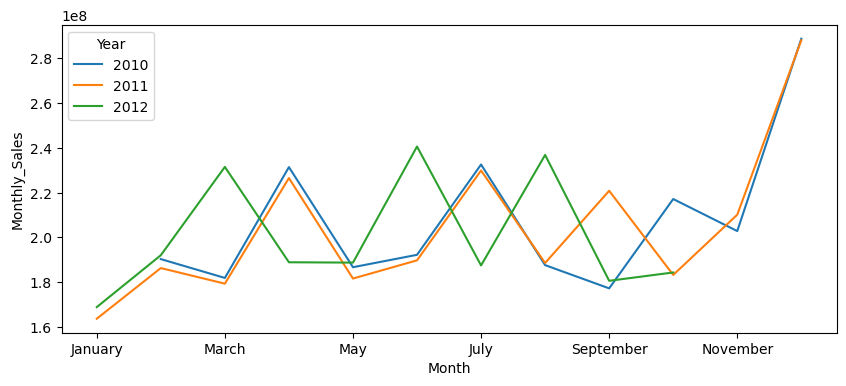

In [43]:
month=df_month
month=df_month.rename(columns={'Weekly_Sales':'Monthly_Sales'})
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
month['Month']=pd.Categorical(month['Month'],categories=month_order, ordered=True)
pivot=month.pivot(index="Month",columns="Year",values="Monthly_Sales")

pivot.plot(kind='line',figsize=(10,4))
plt.xlabel("Month")
plt.ylabel("Monthly_Sales")
plt.show()

### Highest and Lowest Weekly sales made by respective stores, albeit the year: ###

In [ ]:
df_store=df.groupby(['Store'])['Weekly_Sales'].sum().reset_index()
df_store.sort_values(by='Weekly_Sales',ascending=False,inplace=True)

top_store=df_store.iloc[0]
bottom_store=df_store.iloc[-1]
print(f"Max weekly sales done by store {top_store['Store']:.0f}: ${top_store['Weekly_Sales']:,.2f} in 3 consecutive years.")
print(f"Min weekly sales done by store {bottom_store['Store']:.0f}: ${bottom_store['Weekly_Sales']:,.2f} in 3 consecutive years.")

Max weekly sales done by store 20: $301,397,792.46 in 3 consecutive years.
Min weekly sales done by store 33: $37,160,221.96 in 3 consecutive years.


### Year wise store rankings: ###

In [ ]:
for year in df['Year'].unique():
    store_year=df[df['Year']==year]
    store_year=store_year.groupby(['Store','Year'])['Weekly_Sales'].sum().reset_index()
    store_year.sort_values(by='Weekly_Sales',ascending=False,inplace=True,ignore_index=True)

    top_store=store_year.iloc[0]
    bottom_store=store_year.iloc[-1]
    print(f"Max sales done in {year} by store {top_store['Store']:.0f}: ${top_store['Weekly_Sales']:,.2f}")
    print(f"Min sales done in {year} by store {bottom_store['Store']:.0f}: ${bottom_store['Weekly_Sales']:,.2f}\n")


Max sales done in 2010 by store 14: $105,462,242.38
Min sales done in 2010 by store 33: $12,766,834.26

Max sales done in 2011 by store 4: $111,092,293.33
Min sales done in 2011 by store 33: $12,957,836.67

Max sales done in 2012 by store 4: $92,771,189.24
Min sales done in 2012 by store 33: $11,435,551.03



#### Overall we can see that store 33 has the least sales for 3 consecutive years. Additionally store 4 had the highest sales for 2 consecutive years. ####


In [44]:
# I am going to analyze the year 2011 for the stores 4 and 33, as the data for 2012 is only uptil October
df_33 = df[(df['Store']==33) & (df['Year']==2011)]
df_4 = df[(df['Store']==4) & (df['Year']==2011)]
df2= df[(df['Store']==4) & (df['Store']==33)]

In [15]:
pd.set_option('display.width', 200)
cols=['Weekly_Sales','Holiday_Flag','Temperature','Fuel_Price','CPI','Unemployment']
corr1=df_4[cols].corr()
corr2=df_33[cols].corr()
print("Store 4 correlation:")
print(corr1)

print("\nStore 33 correlation:")
print(corr2)

Store 4 correlation:
              Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price   CPI  Unemployment
Weekly_Sales          1.00          0.18        -0.30       -0.26  0.43         -0.46
Holiday_Flag          0.18          1.00        -0.22       -0.21  0.10         -0.11
Temperature          -0.30         -0.22         1.00        0.79  0.27         -0.14
Fuel_Price           -0.26         -0.21         0.79        1.00  0.28         -0.06
CPI                   0.43          0.10         0.27        0.28  1.00         -0.93
Unemployment         -0.46         -0.11        -0.14       -0.06 -0.93          1.00

Store 33 correlation:
              Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price   CPI  Unemployment
Weekly_Sales          1.00          0.14        -0.07        0.13 -0.02          0.02
Holiday_Flag          0.14          1.00        -0.16       -0.19  0.10         -0.13
Temperature          -0.07         -0.16         1.00        0.58  0.32         -0.10
Fuel_Price

### Sales Trend and CPI vs Sales Visualization ###

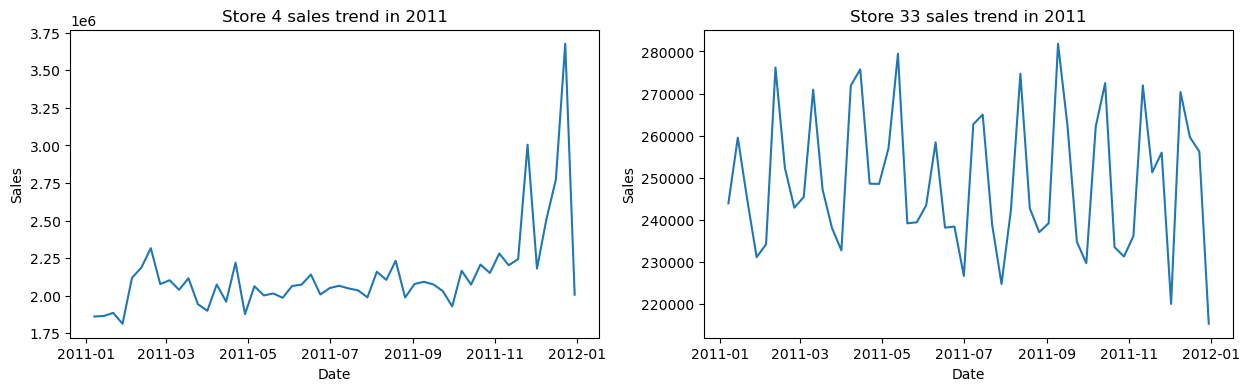

In [23]:
fig, axes = plt.subplots(1,2,figsize=(15,4))
axes[0].plot(df_4['Date'],df_4['Weekly_Sales'],label="Store 4")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Sales")
axes[0].set_title("Store 4 sales trend in 2011")

axes[1].plot(df_33['Date'],df_33['Weekly_Sales'],label="Store 33")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Sales")
axes[1].set_title("Store 33 sales trend in 2011")
plt.show()

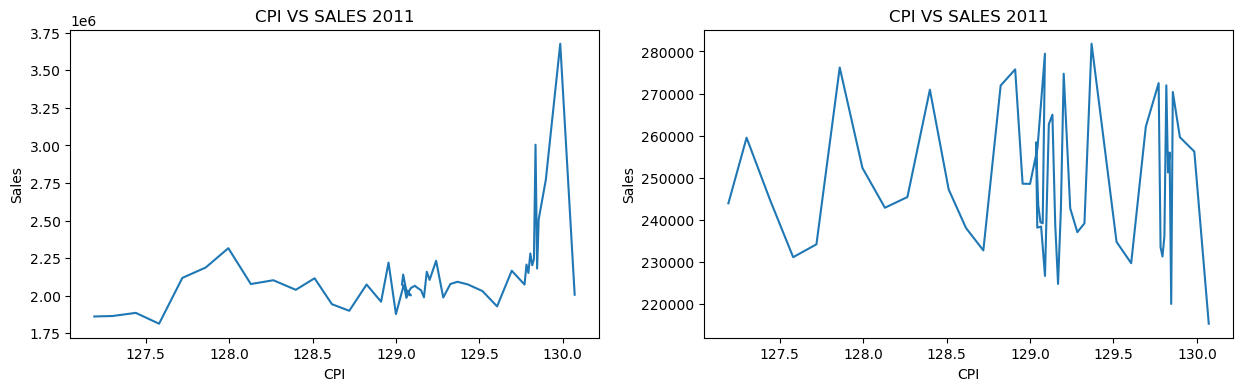

In [59]:
fig, axes = plt.subplots(1,2,figsize=(15,4))
axes[0].plot(df_4['CPI'],df_4['Weekly_Sales'],label="Store 4")
axes[0].set_xlabel("CPI")
axes[0].set_ylabel("Sales")
axes[0].set_title("CPI VS SALES 2011")

axes[1].plot(df_33['CPI'],df_33['Weekly_Sales'],label="Store 33")
axes[1].set_xlabel("CPI")
axes[1].set_ylabel("Sales")
axes[1].set_title("CPI VS SALES 2011")
plt.show()

### Store 4 and 33 comparison ###

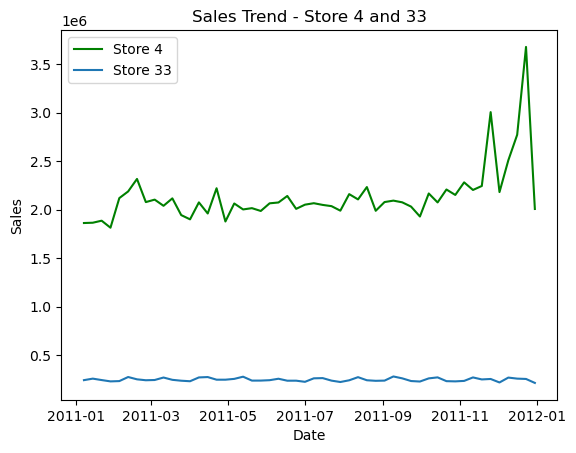

In [51]:
plt.plot(df_4['Date'],df_4['Weekly_Sales'],label="Store 4",color="green")
plt.plot(df_33['Date'],df_33['Weekly_Sales'],label='Store 33')

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Trend - Store 4 and 33")
plt.legend()

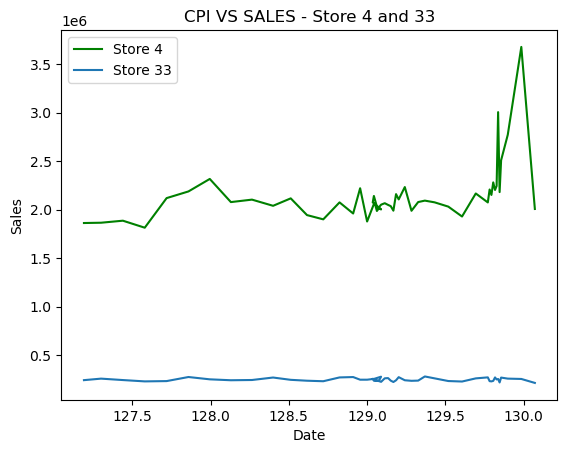

In [52]:
plt.plot(df_4['CPI'],df_4['Weekly_Sales'],label="Store 4",color="green")
plt.plot(df_33['CPI'],df_33['Weekly_Sales'],label='Store 33')

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("CPI VS SALES - Store 4 and 33")
plt.legend()

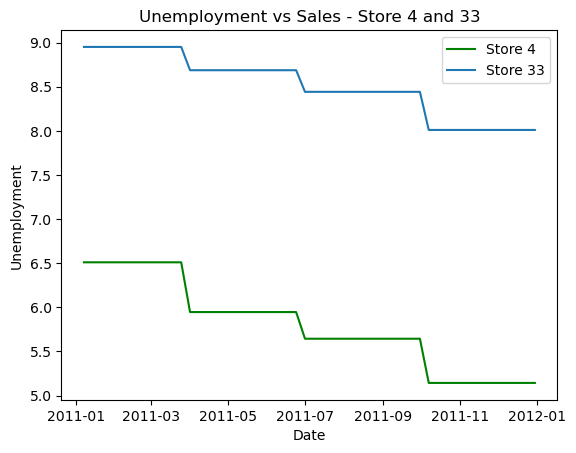

In [58]:
plt.plot(df_4['Date'],df_4['Unemployment'],label="Store 4",color="green")
plt.plot(df_33['Date'],df_33['Unemployment'],label='Store 33')

plt.xlabel("Date")
plt.ylabel("Unemployment")
plt.title("Unemployment vs Sales - Store 4 and 33")
plt.legend()

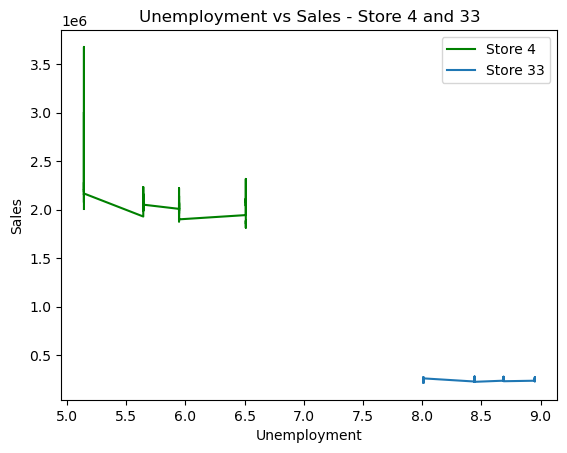

In [57]:
plt.plot(df_4['Unemployment'],df_4['Weekly_Sales'],label="Store 4",color="green")
plt.plot(df_33['Unemployment'],df_33['Weekly_Sales'],label='Store 33')

plt.xlabel("Unemployment")
plt.ylabel("Sales")
plt.title("Unemployment vs Sales - Store 4 and 33")
plt.legend()